In [0]:
import pandas as pd
pd.read_csv("/Volumes/dbacademy/labuser11106168_1754644144/case/housing_data_cleaned_STD.csv")

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
19675,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
19676,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
19677,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
19678,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [0]:
import pandas as pd

spark_df = spark.table("dbacademy.labuser11106168_1754644144.housing_data_cleaned_std")

df = spark_df.toPandas()
display(df)

MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
8.3252,41.0,6.984126984126984,1.0238095238095235,322.0,2.555555555555556,37.88,-122.23,4.526
8.3014,21.0,6.238137082601054,0.9718804920913884,2401.0,2.109841827768014,37.86,-122.22,3.585
7.2574,52.0,8.288135593220339,1.073446327683616,496.0,2.8022598870056497,37.85,-122.24,3.521
5.6431,52.0,5.817351598173516,1.0730593607305936,558.0,2.547945205479452,37.85,-122.25,3.413
3.8462,52.0,6.281853281853282,1.0810810810810811,565.0,2.1814671814671813,37.85,-122.25,3.422
4.0368,52.0,4.761658031088083,1.1036269430051813,413.0,2.139896373056995,37.85,-122.25,2.697
3.6591,52.0,4.9319066147859925,0.95136186770428,1094.0,2.1284046692607004,37.84,-122.25,2.992
3.12,52.0,4.797527047913447,1.061823802163833,1157.0,1.7882534775888717,37.84,-122.25,2.414
2.0804,42.0,4.294117647058823,1.1176470588235294,1206.0,2.026890756302521,37.84,-122.26,2.267
3.6912,52.0,4.970588235294118,0.9901960784313726,1551.0,2.172268907563025,37.84,-122.25,2.611


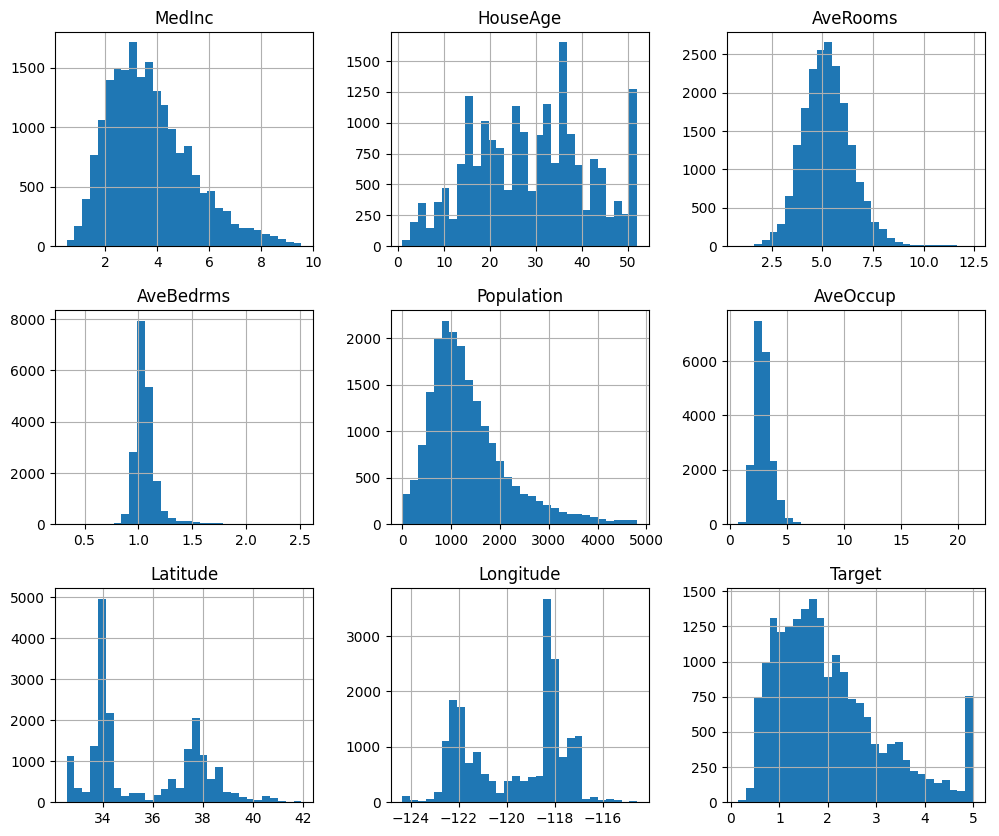

In [0]:
import matplotlib.pyplot as plt
df.hist(bins=30, figsize=(12, 10))
plt.show()

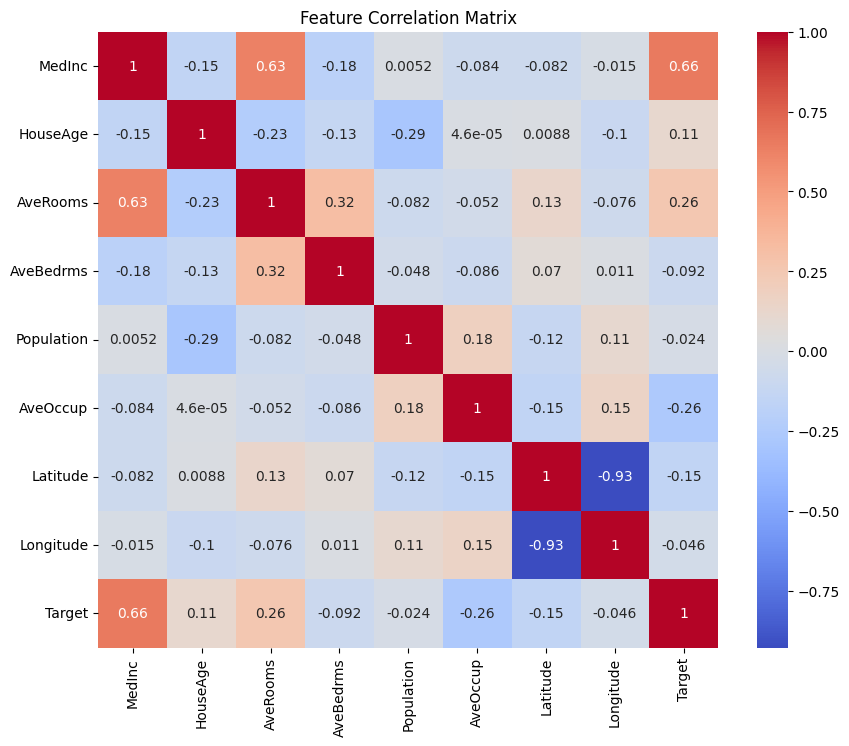

In [0]:
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

<Axes: xlabel='MedInc', ylabel='Target'>

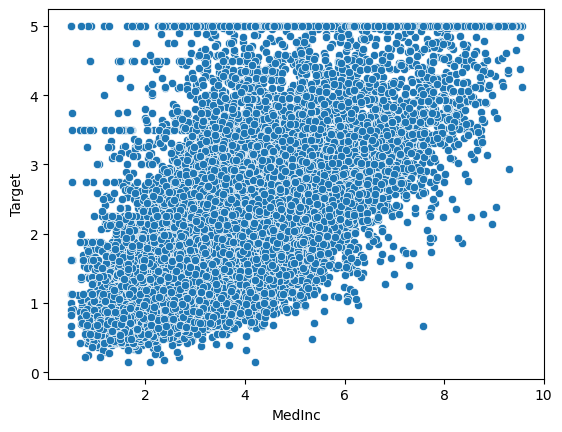

In [0]:
sns.scatterplot(x='MedInc', y='Target', data=df)

In [0]:
# Define feature and target
X = df[['MedInc']]
y = df['Target'] 


# Stratified sampling based on 'Target' bins
from sklearn.model_selection import train_test_split
import numpy as np

# Create bins for stratification
df_clean['Target_bin'] = pd.qcut(df_clean['Target'], q=5, duplicates='drop')
strat_sample, _ = train_test_split(
    df_clean, 
    test_size=0.8, 
    stratify=df_clean['Target_bin'], 
    random_state=42
)
strat_sample = strat_sample.drop(columns=['Target_bin'])

In [0]:
from sklearn.linear_model import LinearRegression

# Use stratified sample
X = strat_sample[['MedInc']]
y = strat_sample['Target']

# Create and fit the model
model = LinearRegression()
model.fit(X, y)

# Predict values
y_pred = model.predict(X)

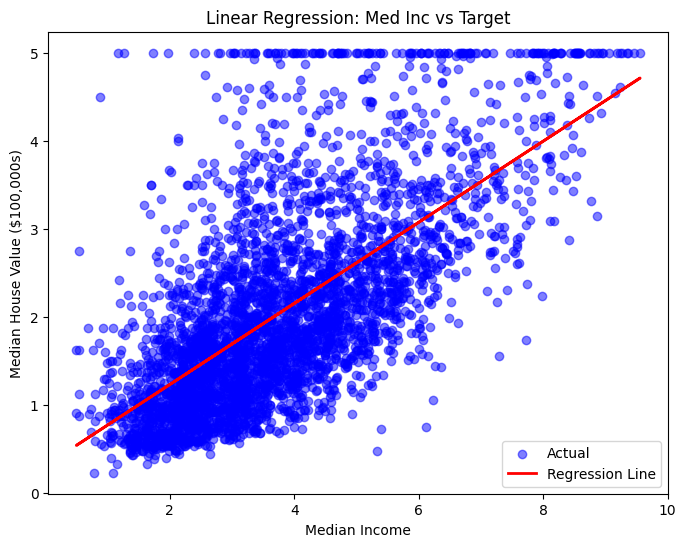

In [0]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', alpha=0.5, label='Actual')
plt.plot(X, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Median Income')
plt.ylabel('Median House Value ($100,000s)')
plt.title('Linear Regression: Med Inc vs Target')
plt.legend()
plt.show()


In [0]:

from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y, y_pred)
rmse = mean_squared_error(y, y_pred, squared=False)

print(f"R² Score: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

R² Score: 0.446
RMSE: 0.833


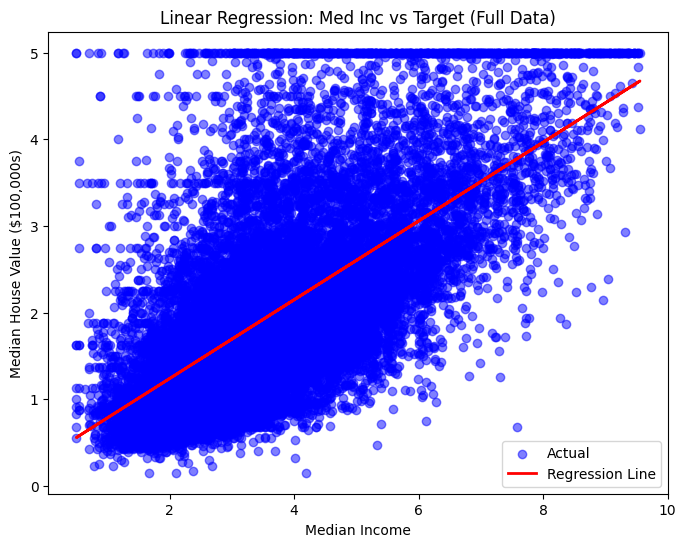

R² Score: 0.434
RMSE: 0.834


In [0]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# Use full dataset
X_full = df[['MedInc']]
y_full = df['Target']

# Create and fit the model
model_full = LinearRegression()
model_full.fit(X_full, y_full)

# Predict values
y_pred_full = model_full.predict(X_full)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(X_full, y_full, color='blue', alpha=0.5, label='Actual')
plt.plot(X_full, y_pred_full, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Median Income')
plt.ylabel('Median House Value ($100,000s)')
plt.title('Linear Regression: Med Inc vs Target (Full Data)')
plt.legend()
plt.show()

# R2 and RMSE
r2_full = r2_score(y_full, y_pred_full)
rmse_full = mean_squared_error(y_full, y_pred_full, squared=False)

print(f"R² Score: {r2_full:.3f}")
print(f"RMSE: {rmse_full:.3f}")